In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import warnings
import matplotlib.pyplot as plt

os.makedirs("models", exist_ok=True)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ( classification_report, confusion_matrix, roc_auc_score, average_precision_score, ConfusionMatrixDisplay )
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("paysim.csv")

df = df.drop(columns=["nameOrig", "nameDest", "isFlaggedFraud", "step"])

print("Dataset shape:", df.shape)
print("Fraud transactions:", df["isFraud"].sum())
print("Fraud rate:", df["isFraud"].mean())

Dataset shape: (6362620, 7)
Fraud transactions: 8213
Fraud rate: 0.001290820448180152


Data Preprocessing

In [3]:
# Add noise to balances
np.random.seed(42)
noise = np.random.normal(0, df["amount"].mean() * 0.15, len(df))

df["newbalanceOrig"] = (df["newbalanceOrig"] + noise).clip(0)
df["newbalanceDest"] = (df["newbalanceDest"] + abs(noise * 0.5)).clip(0)

le = LabelEncoder()
df["type_encoded"] = le.fit_transform(df["type"])

joblib.dump(le, "models/type_encoder.pkl")

['models/type_encoder.pkl']

Feature Engineering

In [4]:
df["amount_log"] = np.log1p(df["amount"])

df["bal_ratio"] = np.where(df["oldbalanceOrg"] > 0, df["amount"] / df["oldbalanceOrg"], 0)
df["is_risky_type"] = df["type"].isin(["TRANSFER", "CASH_OUT"]).astype(int)

In [5]:
legit = df[df["isFraud"] == 0].sample(n=100000, random_state=42 )
fraud = df[df["isFraud"] == 1]

df_sample = pd.concat([legit, fraud]).sample(frac=1, random_state=42)

print("Sample size:", len(df_sample))
print("Fraud count:", df_sample["isFraud"].sum())

Sample size: 108213
Fraud count: 8213


Feature Selection

In [6]:
# Fraud pattern features
df_sample["account_drained"] = (
    (df_sample["newbalanceOrig"] == 0) &
    (df_sample["oldbalanceOrg"] > 0)
).astype(int)

df_sample["receiver_balance_unchanged"] = (
    (df_sample["newbalanceDest"] == df_sample["oldbalanceDest"]) &
    (df_sample["amount"] > 0)
).astype(int)

df_sample["full_balance_transfer"] = (
    df_sample["amount"] == df_sample["oldbalanceOrg"]
).astype(int)

In [7]:
features = [
    "amount",
    "amount_log",
    "oldbalanceOrg",
    "newbalanceOrig",
    "bal_ratio",
    "is_risky_type",
    "type_encoded",
    "account_drained",
    "receiver_balance_unchanged",
    "full_balance_transfer"
]

X = df_sample[features]
y = df_sample["isFraud"]

print("Fraud Rate:", y.mean())
joblib.dump(features, "models/feature_cols.pkl")

Fraud Rate: 0.07589661131287369


['models/feature_cols.pkl']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y )

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, "models/scaler.pkl")

['models/scaler.pkl']

Handling Class Imbalance (SMOTE)

In [10]:
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE")
print("Legit:", (y_train_res == 0).sum())
print("Fraud:", y_train_res.sum())

After SMOTE
Legit: 80000
Fraud: 80000


Model Training

In [12]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_res, y_train_res)
joblib.dump(model, "models/fraud_model.pkl")

['models/fraud_model.pkl']

Model Evaluation

In [13]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("PR AUC:", average_precision_score(y_test, y_prob))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

ROC AUC: 0.9995084905660377
PR AUC: 0.997799542346566

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20000
           1       1.00      1.00      1.00      1643

    accuracy                           1.00     21643
   macro avg       1.00      1.00      1.00     21643
weighted avg       1.00      1.00      1.00     21643



Confusion Matrix

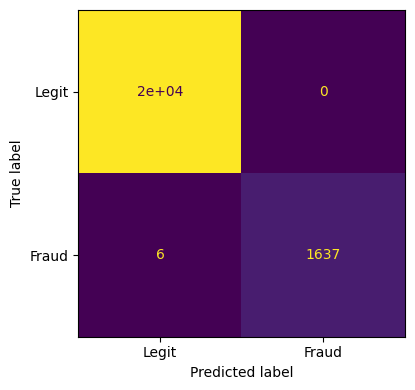

In [14]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay( cm, display_labels=["Legit","Fraud"]).plot(ax=ax, colorbar=False)

plt.tight_layout()
plt.savefig("models/confusion_matrix.png", dpi=150)
plt.show()

Feature Importance

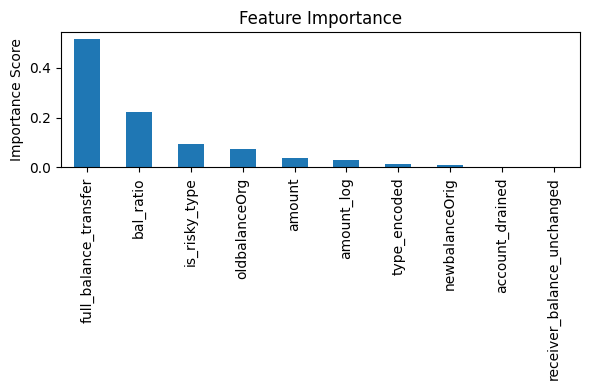

In [15]:
importances = model.feature_importances_

feat_imp = pd.Series(importances, index=features)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(6,4))
feat_imp.plot(kind="bar")

plt.title("Feature Importance")
plt.ylabel("Importance Score")

plt.tight_layout()
plt.show()